In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

image, label = train_data[0]
print(f"Image shape: {image.shape}")
print(f"Label: {label}")

Image shape: torch.Size([1, 28, 28])
Label: 5


In [ ]:
class MultiClassANN(nn.Module):
  def __init__(self, input_size, hidden_size, num_classes):
    super(MultiClassANN, self).__init__()
    self.fc1 = nn.Linear(input_size, hidden_size)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(hidden_size, hidden_size)
    self.relu = nn.ReLU()
    self.fc3 = nn.Linear(hidden_size, hidden_size)
    self.relu = nn.ReLU()
    self.fc4 = nn.Linear(hidden_size, num_classes)
  def forward(self, x):
    x=self.fc1(x)
    x=self.relu(x)
    x=self.fc2(x)
    x=self.relu(x)
    x=self.fc3(x)
    x=self.relu(x)
    x=self.fc4(x)
    return x


In [ ]:
loss=nn.CrossEntropyLoss(weight = None, reduction = 'mean')
model = MultiClassANN(784, 128, 10)
optimizer = optim.Adam(model.parameters(), lr=0.01)
nn.Softmax(1)

Softmax(dim=1)

In [ ]:
def training(model, dataloader, loss, optimizer):
  model.train()
  t_loss = 0

  for batch_idx, (input, label) in enumerate(dataloader):
    outputs = model(input)
    l=loss(outputs, label)

    optimizer.zero_grad()
    l.backward()
    optimizer.step()

    t_loss += l.item()

  return t_loss/len(dataloader)

In [ ]:
x_tensor = []
y_tensor = []

transform = transforms.Compose([
    transforms.ToTensor(),
])

for images, labels in train_data:
    x_tensor.append(images.view(-1))
    y_tensor.append(labels)

x_tensor = torch.stack(x_tensor)
y_tensor = torch.tensor(y_tensor)

dataset = TensorDataset(x_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)
model = MultiClassANN(784, 256, 10)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
for epoch in range(num_epochs):
    epoch_loss = training(model, dataloader, criterion, optimizer)
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

Epoch 1, Loss: 0.2638
Epoch 2, Loss: 0.0994
Epoch 3, Loss: 0.0681
Epoch 4, Loss: 0.0530
Epoch 5, Loss: 0.0437
Epoch 6, Loss: 0.0347
Epoch 7, Loss: 0.0323
Epoch 8, Loss: 0.0263
Epoch 9, Loss: 0.0222
Epoch 10, Loss: 0.0208


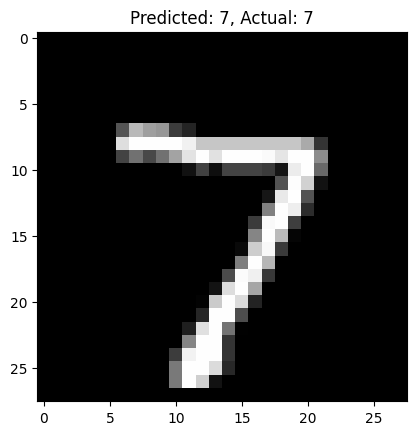

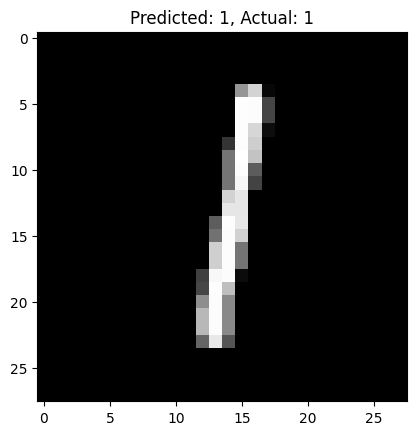

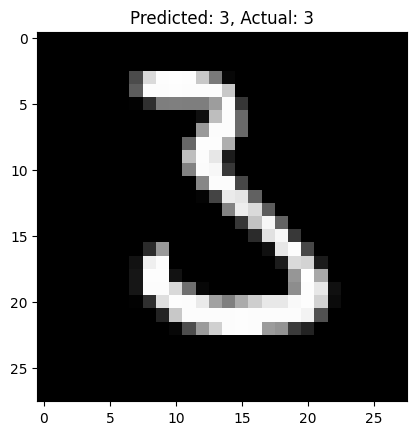

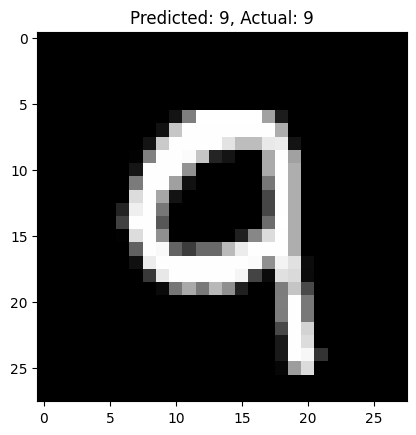

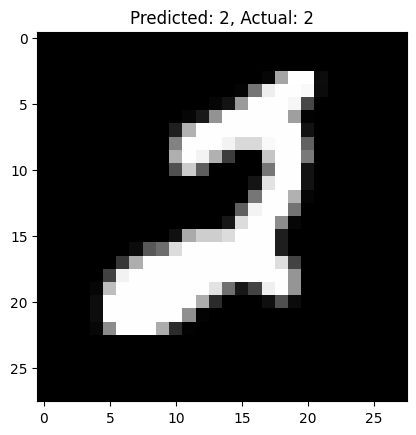

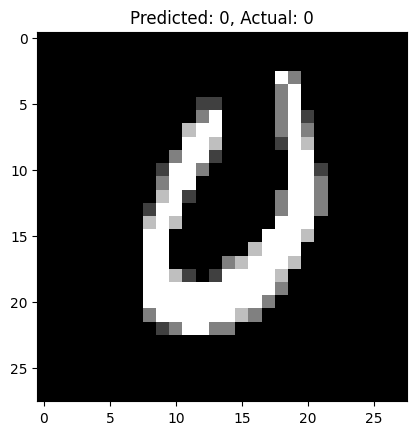

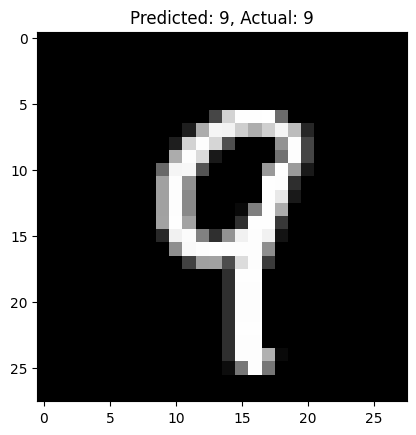

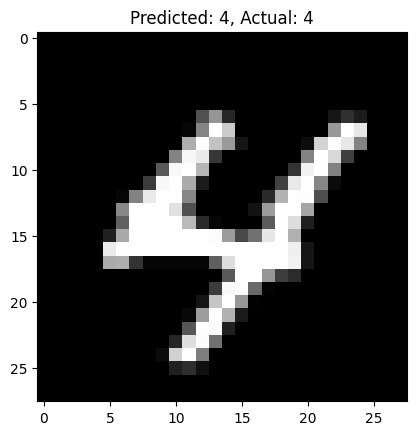

Test Accuracy: 97.82%
Test Loss: 0.0782


In [ ]:
def test(model, dataloader, loss):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_idx, (input, label) in enumerate(dataloader):

            outputs = model(input)
            l = loss(outputs, label)

            total_loss = total_loss + l.item()

            predictions = torch.argmax(outputs, dim=1)

            correct += (predictions == label).sum().item()
            total += label.size(0)

            if batch_idx % 20 == 0:
              plt.imshow(input[0].view(28, 28).numpy(), cmap='gray')
              plt.title(f"Predicted: {predictions[0].item()}, Actual: {label[0].item()}")
              plt.show()

    avg_loss = total_loss / (batch_idx + 1)
    accuracy = 100 * correct / total
    return accuracy, avg_loss

x_test_tensor = []
y_test_tensor = []

for images, labels in test_data:
    x_test_tensor.append(images.view(-1))
    y_test_tensor.append(labels)

x_test_tensor = torch.stack(x_test_tensor)
y_test_tensor = torch.tensor(y_test_tensor)

test_dataset = TensorDataset(x_test_tensor, y_test_tensor)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

test_accuracy, test_loss = test(model, test_dataloader, criterion)

print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Test Loss: {test_loss:.4f}")